# 04 - RAG Evaluation with RAGAS + OpenRouter Judge

This notebook evaluates RAG quality using the **RAGAS** framework.

We compute core RAGAS metrics:
- Context Precision
- Context Recall
- Response Relevancy
- Faithfulness

Judge model: `openai/gpt-4o-mini:floor` via OpenRouter.

Steps:
1. Load retrieved contexts and drafted answers.
2. Build a RAGAS evaluation dataset (`user_input`, `response`, `retrieved_contexts`, `reference`).
3. Run RAGAS evaluation with OpenRouter judge LLM.
4. Save and summarize metric outputs.

Outputs: `data/processed/ragas_results.json`.

In [1]:
%load_ext autoreload
%autoreload 2

In [20]:
import json
import pandas as pd
import logging
from pathlib import Path

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Paths
DATA_PROCESSED = Path('../data/processed')
RETRIEVED_CONTEXTS_PATH = DATA_PROCESSED / 'retrieved_contexts.json'
DRAFT_PATH = DATA_PROCESSED / 'draft2_refined.csv'
GROUND_TRUTH_PATH = DATA_PROCESSED / 'ground_truth_final.json'
RAGAS_OUTPUT_PATH = DATA_PROCESSED / 'ragas_results.json'

# Imports
from biotech_rag.evaluation.ragas_runner import (
    build_evaluation_dataset,
    default_ragas_metrics,
    make_ragas_embeddings,
    make_ragas_llm,
    run_ragas_evaluation,
)
from biotech_rag.evaluation.visualize import plot_rag_metrics

In [3]:
# Load data
with open(RETRIEVED_CONTEXTS_PATH, 'r', encoding='utf-8') as f:
    retrieved_records = json.load(f)

# Load draft answers (prefer CSV that contains draft_citations/draft_answer)
try:
    with open(DRAFT_PATH, 'r', encoding='utf-8') as f:
        draft_records = json.load(f)
except Exception:
    try:
        df = pd.read_csv(DRAFT_PATH)
        draft_records = df.to_dict(orient='records')
    except Exception:
        import csv
        with open(DRAFT_PATH, 'r', encoding='utf-8', newline='') as f:
            reader = csv.DictReader(f)
            draft_records = [dict(r) for r in reader]

# Recover list-like fields encoded as strings (e.g., draft_citations)
import ast
for rec in draft_records:
    for key in (
        'retrieved_chunks',
        'retrieved_contexts',
        'draft_citations',
        'draft_missing_info',
        'draft_confidence',
        'draft_answer',
        'revised_answer',
    ):
        if key in rec and isinstance(rec[key], str):
            s = rec[key].strip()
            if s.startswith('[') and s.endswith(']'):
                try:
                    rec[key] = ast.literal_eval(s)
                except Exception:
                    pass

with open(GROUND_TRUTH_PATH, 'r', encoding='utf-8') as f:
    ground_truth_records = json.load(f)


def _normalize_key(value):
    if value is None:
        return None
    text = str(value).strip()
    return text.lower() if text else None

retrieved_by_row = {_normalize_key(r.get('row_id')): r for r in retrieved_records if _normalize_key(r.get('row_id')) is not None}
retrieved_by_nct = {_normalize_key(r.get('nct_id')): r for r in retrieved_records if _normalize_key(r.get('nct_id')) is not None}
retrieved_by_question = {_normalize_key(r.get('question')): r for r in retrieved_records if _normalize_key(r.get('question')) is not None}

ground_truth_by_row = {_normalize_key(g.get('row_id')): g for g in ground_truth_records if _normalize_key(g.get('row_id')) is not None}
ground_truth_by_nct = {_normalize_key(g.get('nct_id')): g for g in ground_truth_records if _normalize_key(g.get('nct_id')) is not None}
ground_truth_by_question = {_normalize_key(g.get('question')): g for g in ground_truth_records if _normalize_key(g.get('question')) is not None}

merged_records = []
unmatched_draft = 0
matched_references = 0

for draft in draft_records:
    row_key = _normalize_key(draft.get('row_id'))
    nct_key = _normalize_key(draft.get('nct_id'))
    question_key = _normalize_key(draft.get('question'))

    retrieved_match = (
        retrieved_by_row.get(row_key)
        or retrieved_by_nct.get(nct_key)
        or retrieved_by_question.get(question_key)
    )
    if retrieved_match is None:
        unmatched_draft += 1
        continue

    # Improved ground-truth matching logic
    ground_truth_match = None
    candidates = [g for g in ground_truth_records if _normalize_key(g.get('nct_id')) == nct_key] if nct_key else []

    # 1) prefer exact question match among same-NCT candidates
    if question_key and candidates:
        for g in candidates:
            if _normalize_key(g.get('question')) == question_key:
                ground_truth_match = g
                break

    # 2) global question match
    if ground_truth_match is None and question_key:
        ground_truth_match = ground_truth_by_question.get(question_key)

    # 3) row_id match
    if ground_truth_match is None and row_key:
        ground_truth_match = ground_truth_by_row.get(row_key)

    # 4) fallback to single candidate for NCT if unique
    if ground_truth_match is None and len(candidates) == 1:
        ground_truth_match = candidates[0]

    # Merge: prefer draft fields where available
    merged = {**retrieved_match, **draft}

    # Avoid carrying unrelated 'reference' from retrieved records
    merged['reference'] = None
    merged['ground_truth_source_chunks'] = None

    # Ensure evaluator uses the draft question as the user_input key
    merged['user_input'] = draft.get('question') or merged.get('question') or draft.get('nct_id') or ''

    # Primary source for contexts: draft_citations from draft2_refined.csv
    draft_citations = draft.get('draft_citations') or draft.get('draft_chunks')
    if isinstance(draft_citations, str):
        try:
            draft_citations = ast.literal_eval(draft_citations)
        except Exception:
            draft_citations = [draft_citations]

    if draft_citations:
        merged['retrieved_contexts'] = [str(x).strip() for x in draft_citations if str(x).strip()]
    else:
        merged['retrieved_contexts'] = (
            merged.get('retrieved_contexts')
            or merged.get('retrieved_chunks')
            or merged.get('contexts')
            or []
        )

    # RESPONSE: use draft_answer (from draft2_refined.csv) as the system response to evaluate
    resp = draft.get('draft_answer') or draft.get('revised_answer') or merged.get('response')
    merged['response'] = resp.strip() if isinstance(resp, str) else (resp or '')

    # REFERENCE: use ONLY the canonical expert answer from ground_truth_final.json
    if ground_truth_match is not None:
        reference_text = ground_truth_match.get('ground_truth_answer')
        if isinstance(reference_text, str) and reference_text.strip():
            merged['reference'] = reference_text.strip()
            # also keep the gold source chunks for context-precision/recall checks
            merged['ground_truth_source_chunks'] = ground_truth_match.get('source_chunks') or ground_truth_match.get('source_documents') or None
            matched_references += 1

    merged_records.append(merged)

logger.info(f"Loaded {len(merged_records)} merged records for evaluation.")
print(f"Sample merged record keys: {list(merged_records[0].keys()) if merged_records else 'None'}")
print(f"Matched references: {matched_references}/{len(merged_records)}")
print(f"Draft records without retrieval match: {unmatched_draft}")

INFO:__main__:Loaded 200 merged records for evaluation.


Sample merged record keys: ['row_id', 'nct_id', 'question', 'retrieved_chunks', 'metadatas', 'chunk_ids', 'draft_answer', 'draft_citations', 'draft_confidence', 'draft_missing_info', 'expert_notes', 'revised_answer', 'reference', 'ground_truth_source_chunks', 'user_input', 'retrieved_contexts', 'response']
Matched references: 200/200
Draft records without retrieval match: 0


In [4]:
# RAGAS evaluation with OpenRouter judge
SAMPLE_N = 10
JUDGE_MODEL = 'openai/gpt-4o-mini:floor'

# Build dataset and evaluator clients
dataset = build_evaluation_dataset(records=merged_records, sample_n=SAMPLE_N)
evaluator_llm = make_ragas_llm(model=JUDGE_MODEL, temperature=0.0, max_tokens=2000)
evaluator_embeddings = make_ragas_embeddings()
metrics = default_ragas_metrics(llm=evaluator_llm, embeddings=evaluator_embeddings)

# Run evaluation (may call external LLMs)
ragas_result_payload = run_ragas_evaluation(
    dataset=dataset,
    llm=evaluator_llm,
    metrics=metrics,
    embeddings=evaluator_embeddings,
    output_path=RAGAS_OUTPUT_PATH,
    # allow_retries=True,  # Optional: enable if you want retry logic
)

metric_names = ragas_result_payload.get('metric_names', [])
logger.info('RAGAS evaluation completed with %d metrics.', len(metric_names))
print(f'Judge model: {JUDGE_MODEL}')
print(f'Sample size: {SAMPLE_N}')
print(f"Metrics: {', '.join(metric_names) if metric_names else 'Unavailable'}")
print(f"Results saved to: {ragas_result_payload.get('output_path', str(RAGAS_OUTPUT_PATH))}")

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

INFO:biotech_rag.generation.llm_clients:Using cached response for openai/gpt-4o-mini:floor
INFO:biotech_rag.generation.llm_clients:Using cached response for openai/gpt-4o-mini:floor
INFO:biotech_rag.generation.llm_clients:Using cached response for openai/gpt-4o-mini:floor
INFO:biotech_rag.generation.llm_clients:Using cached response for openai/gpt-4o-mini:floor
INFO:biotech_rag.generation.llm_clients:Using cached response for openai/gpt-4o-mini:floor
INFO:biotech_rag.generation.llm_clients:Using cached response for openai/gpt-4o-mini:floor
INFO:biotech_rag.generation.llm_clients:Using cached response for openai/gpt-4o-mini:floor
INFO:biotech_rag.generation.llm_clients:Using cached response for openai/gpt-4o-mini:floor
INFO:biotech_rag.generation.llm_clients:Using cached response for openai/gpt-4o-mini:floor
INFO:biotech_rag.generation.llm_clients:Using cached response for openai/gpt-4o-mini:floor
INFO:biotech_rag.generation.llm_clients:Using cached response for openai/gpt-4o-mini:floor

[context_precision judge] row 0 → AP=0.833  relevance=[1, 1, 0, 0, 0, 1, 0, 0, 0, 0]
[context_precision judge] row 1 → AP=1.000  relevance=[1, 1, 1, 0, 0, 0, 0, 0, 0, 0]
[context_precision judge] row 2 → AP=1.000  relevance=[1, 1, 1, 1]
[context_precision judge] row 3 → AP=1.000  relevance=[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[context_precision judge] row 4 → AP=0.000  relevance=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[context_precision judge] row 5 → AP=1.000  relevance=[1, 1]
[context_precision judge] row 6 → AP=1.000  relevance=[1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[context_precision judge] row 7 → AP=0.500  relevance=[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[context_precision judge] row 8 → AP=1.000  relevance=[1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[context_precision judge] row 9 → AP=0.000  relevance=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[answer_relevancy judge] row 0 → 0.80  (raw='0.8')
[answer_relevancy judge] row 1 → 1.00  (raw='1.0')
[answer_relevancy judge] row 2 → 1.00  (raw='1.0')
[answer_relevancy judge] row 3 → 0.80  

In [ ]:
# Final evaluation summary

if 'ragas_result_payload' not in globals():
    print('No RAGAS result payload found. Run the evaluation cell first.')
else:
    import pandas as pd

    summary = ragas_result_payload.get('summary') or {}
    rows = ragas_result_payload.get('rows', [])

    # Display clean summary — RAGAS alias keys were already removed
    print('=== RAG Evaluation Summary (final) ===')
    _METRIC_ORDER = [
        'context_precision', 'context_recall',
        'answer_relevancy', 'faithfulness',
        'factual_correctness(mode=f1)', 'semantic_similarity',
    ]
    # Print in canonical order first, then any extras
    printed = set()
    for name in _METRIC_ORDER:
        if name in summary:
            print(f'  {name}: {summary[name]:.3f}')
            printed.add(name)
    for name, value in sorted(summary.items()):
        if name not in printed and isinstance(value, (int, float)):
            print(f'  {name}: {value:.3f}')

    # Per-sample table
    if rows:
        df_rows = pd.DataFrame(rows)
        # Drop verbose columns for display
        drop_cols = [c for c in df_rows.columns if c in ('retrieved_contexts', 'metadata', 'ground_truth_source_chunks')]
        df_display = df_rows.drop(columns=[c for c in drop_cols if c in df_rows.columns])
        print(f'\nPer-sample results ({len(rows)} rows):')
        display(df_display)


=== RAG Evaluation Summary (final) ===
  context_precision: 0.733
  context_recall: 0.900
  answer_relevancy: 0.900
  faithfulness: 0.972
  factual_correctness(mode=f1): 0.901
  semantic_similarity: 0.918

Per-sample results (10 rows):


,user_input,response,reference,context_recall,answer_relevancy,faithfulness,factual_correctness(mode=f1),semantic_similarity,context_precision
0,For Clinical Study NCT04205812 titled 'Platinu...,Participants in the clinical trial NCT04205812...,Participants in the clinical trial NCT04205812...,0.5,0.8,1.000000,0.77,0.968978,0.833333
1,For Clinical Study NCT04205812 titled 'Platinu...,Exclusion criteria for Clinical Study NCT04205...,Exclusion criteria for Clinical Study NCT04205...,1.0,1.0,1.000000,1.00,0.999896,1.000000
2,For Clinical Study NCT04205812 titled 'Platinu...,"The trial NCT04205812 was a randomized, double...","The trial NCT04205812 was a randomized, double...",1.0,1.0,0.833333,1.00,1.000000,1.000000
3,For Clinical Study NCT04205812 titled 'Platinu...,The primary endpoint of the study NCT04205812 ...,The primary endpoint of the study NCT04205812 ...,1.0,0.8,1.000000,0.86,0.953102,1.000000
4,For Clinical Study NCT04205812 titled 'Platinu...,The secondary endpoints assessed in the study ...,The secondary endpoints assessed in the study ...,1.0,1.0,1.000000,1.00,0.959239,0.000000
5,For Clinical Study NCT04205812 titled 'Platinu...,The primary endpoint of overall survival was m...,The primary endpoint of overall survival was m...,0.5,1.0,0.888889,1.00,1.000000,1.000000
6,For Clinical Study NCT04205812 titled 'Platinu...,The key secondary endpoint findings for Clinic...,The key secondary endpoint findings for Clinic...,1.0,0.8,1.000000,0.71,0.893788,1.000000
7,For Clinical Study NCT04205812 titled 'Platinu...,"In the retifanlimab plus chemotherapy group, 6...","In the clinical trial NCT04205812, the retifan...",1.0,0.8,1.000000,1.00,0.681472,0.500000
8,For Clinical Study NCT04205812 titled 'Platinu...,The primary analysis likely used Kaplan-Meier ...,The primary analysis for Clinical Study NCT042...,1.0,0.8,1.000000,0.67,0.720261,1.000000
9,For Clinical Study NCT04205812 titled 'Platinu...,There is no evidence in the provided contexts ...,There is no evidence in the provided contexts ...,1.0,1.0,1.000000,1.00,0.999833,0.000000


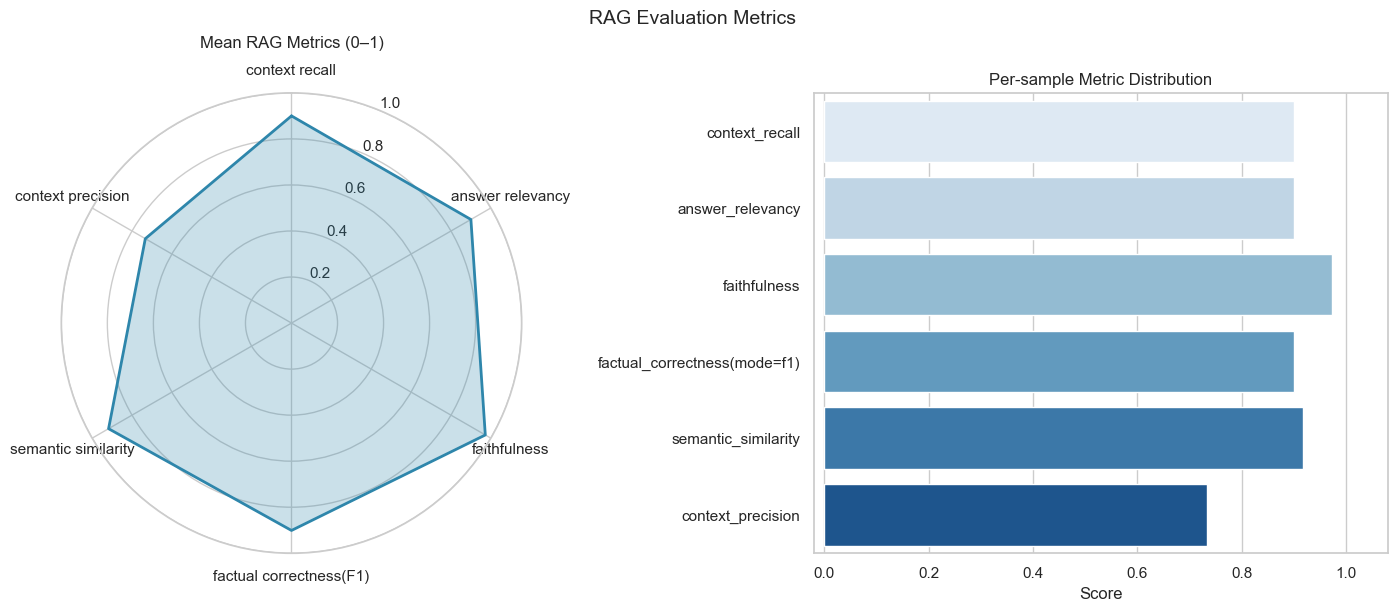

In [25]:
# Plot RAG metrics using shared helper


# df_display is produced in the "Final evaluation summary" cell above
plot_rag_metrics(df_display)


## Conclusion (Medical RAG – RAGAS)

Overall, the pipeline shows **strong clinical grounding and correctness** with high alignment to expected references, and the retrieved evidence generally supports generating relevant, on-question medical answers.

- **Retrieval quality is strong:** context recall (0.900) suggests the system consistently brings in the necessary supporting material, and context precision (0.733) indicates most retrieved context is relevant, with some remaining noise.
- **Grounding is excellent:** faithfulness (0.972) is very high, implying the model’s statements are consistently supported by the provided context—an important safety property for medical settings.
- **Clinical alignment metrics are high:** factual correctness F1 (0.901) and semantic similarity (0.918) indicate the generated answers are typically correct and closely match reference answers in meaning.
- **User-facing usefulness is strong:** answer relevancy (0.900) indicates the system generally addresses the user’s clinical question directly rather than drifting into tangential details.

Taken together, these scores reflect a Medical RAG system that is reliably evidence-grounded, highly accurate relative to references, and consistently produces relevant clinical responses.